# Week 6: Generative Adversarial Networks (GANs)
### Author: Rajit Rajpal
The goal of this tutorial will be to learn about GANs, its associated problems in mode collapse and instability, and some variants offering solutions to said problems. `# TODO` are for you to implement. Solutions will contain the completed code.

### Imports

In [ ]:
# %pip install numpy matplotlib torch torchvision scipy pillow scikit-learn <- Uncomment and run this if you do not have the necessary packages.

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
from torchvision import datasets, transforms
from torchvision.utils import make_grid
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import PIL.Image
from scipy.ndimage import gaussian_filter

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1 Mathematical Foundation
Generative Adversarial Networks (GANs) consist of two networks playing a minimax game.
![GAN Example](GANs.png)

**The Discriminator (D):** Tries to distinguish between real data and fake data.

**The Generator (G):** Tries to map a latent noise vector \( z \) to the data distribution to fool the Discriminator.

The original objective function is defined by the **binary cross-entropy**:

$$
\min_G \max_D \; V(D,G)
=
\mathbb{E}_{x \sim p_{\text{data}}(x)} \left[ \log D(x) \right]
+
\mathbb{E}_{z \sim p_z(z)} \left[ \log\big(1 - D(G(z))\big) \right]
$$


# 2 Setup and Data Loading

In [20]:
# --- Visualization Utility ---
def plot_results(G, D, history, title):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5))
    
    # --- Setup Grid for Density ---
    x = np.linspace(-1.2, 1.2, 100)
    y = np.linspace(-1.2, 1.2, 100)
    X, Y = np.meshgrid(x, y)
    grid = torch.FloatTensor(np.c_[X.ravel(), Y.ravel()]).to(device)
    
    with torch.no_grad():
        # Discriminator landscape
        Z = D(grid).reshape(X.shape).cpu().numpy()
        # Generated samples
        z = torch.randn(2000, 2).to(device)
        fake = G(z).cpu().numpy()
    
    real_samples = get_cat_samples(1000).numpy()

    # 1. Plot: Generated Samples vs Ground Truth
    ax1.scatter(real_samples[:, 0], real_samples[:, 1], s=2, color='green', alpha=0.2, label='Real (Cat)')
    ax1.scatter(fake[:, 0], fake[:, 1], s=2, color='hotpink', alpha=0.6, label='Fake')
    ax1.set_title(f"{title}: Samples")
    ax1.set_xlim(-1.2, 1.2); ax1.set_ylim(-1.2, 1.2)
    ax1.legend()
    
    # 2. Plot: Discriminator Density Map
    # This shows what the Discriminator "thinks" of the space
    im = ax2.imshow(Z, extent=[-1.2, 1.2, -1.2, 1.2], origin='lower', cmap='magma')
    fig.colorbar(im, ax=ax2, label='D(x) Score')
    ax2.set_title(f"{title}: D Density")
    
    # 3. Plot: Loss History
    ax3.plot(history['d_loss'], label='D Loss', alpha=0.8)
    ax3.plot(history['g_loss'], label='G Loss', alpha=0.8)
    ax3.set_title("Training History")
    ax3.set_xlabel("Epoch")
    ax3.legend()
    
    plt.tight_layout()
    plt.show()

def get_cat_samples(n_samples=10000, sigma=2.0):
    try:
        # Load image and convert to grayscale
        cat = PIL.Image.open("cat.png").convert('L')
        arr = 1.0 - (np.array(cat) / 255.0) # Invert so cat is high density (1)
        
        # Apply Gaussian Blur to smooth the distribution
        smoothed_arr = gaussian_filter(arr, sigma=sigma)
        # Normalize to make it a valid probability map
        prob_map = smoothed_arr / smoothed_arr.sum()
    except FileNotFoundError:
        print("Cat image not found, using a fallback density.")
        # Fallback to a simple 2D Gaussian if file is missing
        return torch.randn(n_samples, 2) * 0.5

    # Rejection Sampling or Weighted Sampling
    flat_probs = prob_map.flatten()
    indices = np.random.choice(len(flat_probs), size=n_samples, p=flat_probs)
    
    # Convert 1D indices back to 2D coordinates
    rows, cols = np.unravel_index(indices, prob_map.shape)
    
    # Map to [-1, 1] range
    points = np.zeros((n_samples, 2))
    points[:, 0] = (cols / prob_map.shape[1]) * 2 - 1
    points[:, 1] = 1 - (rows / prob_map.shape[0]) * 2
    
    # Add a tiny bit of noise to prevent points from collapsing onto pixel grid
    points += np.random.normal(0, 0.01, points.shape)
    
    return torch.from_numpy(points).float()

cat_points = get_cat_samples(10000, sigma=3.0)

# 3 The Vanilla GAN: Instability and Mode Collapse
The "Standard" GAN uses a Sigmoid output and Binary Cross Entropy.

Issues:

**Vanishing Gradients**: If D gets too good, the gradient for G becomes zero.

**Mode Collapse**: The generator finds one "safe" spot (e.g., just the cat's ear) and puts all its probability mass there.

### 3.1 Architecture

In [15]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 2))
    def forward(self, z): return self.net(z)

class Discriminator(nn.Module):
    def __init__(self, use_sigmoid=True):
        super().__init__()
        self.use_sigmoid = use_sigmoid
        self.net = nn.Sequential(
            nn.Linear(2, 128), nn.LeakyReLU(0.2),
            nn.Linear(128, 128), nn.LeakyReLU(0.2),
            nn.Linear(128, 1))
    def forward(self, x):
        out = self.net(x)
        return torch.sigmoid(out) if self.use_sigmoid else out

### 3.2 Vanilla GAN (Saturating vs Non-Saturating)

The original GAN objective is based on a minimax game using the **Jensen–Shannon Divergence**.

##### The Minimax Objective
$$
\min_G \max_D \; V(D,G)
=
\mathbb{E}_{x\sim p_{\text{data}}}\big[\log D(x)\big]
+
\mathbb{E}_{z\sim p_z}\big[\log(1-D(G(z)))\big]
$$

**The Problem:**  
In the early stages of training, $G$ is very poor. $D$ can distinguish fakes with near 100% certainty, causing the gradient of  
$\log(1-D(G(z)))$ to **saturate** (flatten).

**The Solution (Non-Saturating Loss):**  
Instead of minimizing the probability that $D$ is correct, $G$ maximizes the probability that $D$ is wrong:

$$
L_G = -\mathbb{E}_{z\sim p_z}\big[\log D(G(z))\big]
$$

This demonstrates the standard Binary Cross Entropy approach. Notice if the "cat" points are too far from the random initialization, the gradients might vanish.

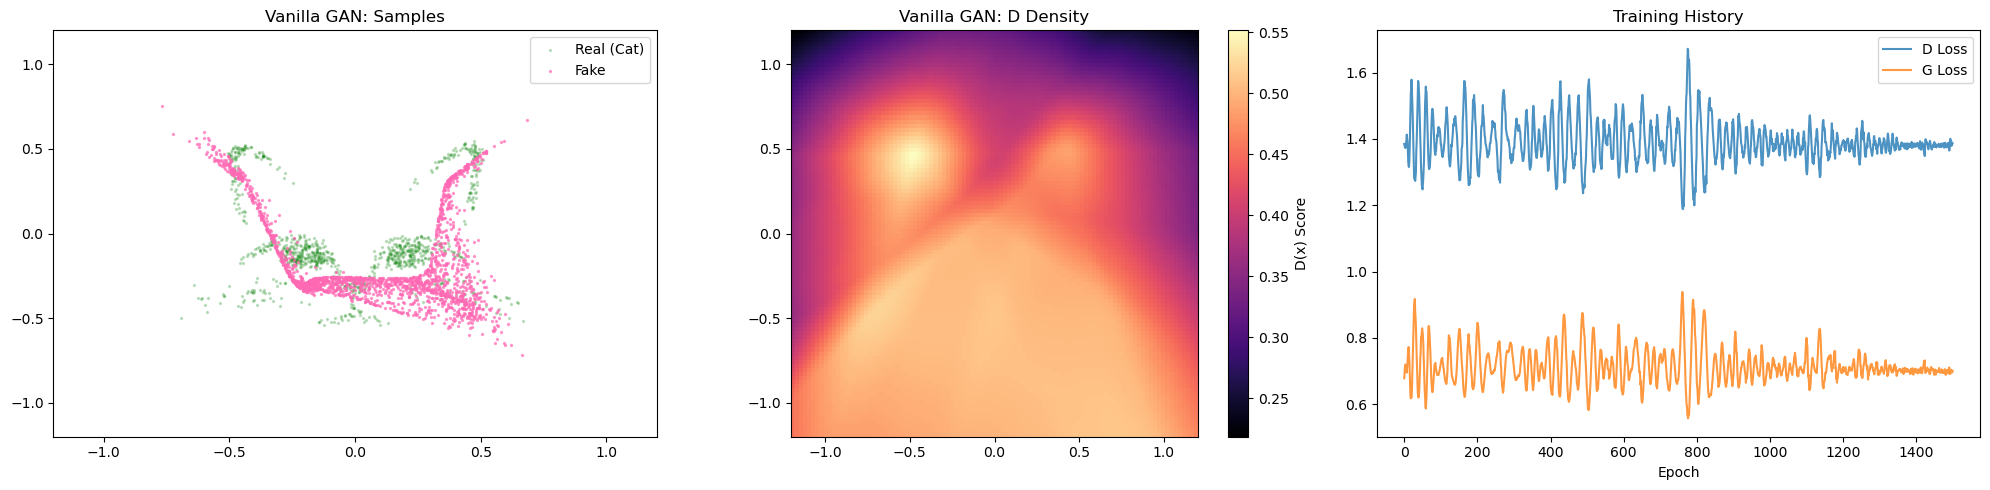

In [21]:
# Training Config
epochs, lr, batch_size = 1500, 1e-3, 128
G = Generator().to(device); D = Discriminator(use_sigmoid=True).to(device)
opt_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.9))
opt_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.9))
criterion = nn.BCELoss()
history = {'d_loss': [], 'g_loss': []}

for epoch in range(epochs):
    real_data = get_cat_samples(batch_size).to(device)
    z = torch.randn(batch_size, 2).to(device)
    fake_data = G(z)

    # D Step
    opt_D.zero_grad()
    loss_D = criterion(D(real_data), torch.ones(batch_size, 1).to(device)) + \
             criterion(D(fake_data.detach()), torch.zeros(batch_size, 1).to(device))
    loss_D.backward(); opt_D.step()

    # G Step (Non-Saturating)
    opt_G.zero_grad()
    loss_G = criterion(D(fake_data), torch.ones(batch_size, 1).to(device))
    loss_G.backward(); opt_G.step()
    
    history['d_loss'].append(loss_D.item()); history['g_loss'].append(loss_G.item())

plot_results(G, D, history, "Vanilla GAN")

### 3.3 Least Squares GAN (LSGAN)

LSGAN replaces the **Binary Cross Entropy (BCE)** loss with **Mean Squared Error (MSE)**.

**Problem with BCE:**  
Once a fake sample is on the "correct" side of the decision boundary, the Vanilla GAN no longer strongly penalizes it. This can produce samples that still look fake.

**Solution:**  
MSE forces the Generator to push samples closer to the real data manifold by minimizing the distance to the real label (1).

##### Discriminator Loss
$$
\min_D \; \frac{1}{2}\mathbb{E}_{x\sim p_{\text{data}}}\big[(D(x)-1)^2\big]
+
\frac{1}{2}\mathbb{E}_{z\sim p_z}\big[D(G(z))^2\big]
$$

##### Generator Loss
$$
\min_G \; \frac{1}{2}\mathbb{E}_{z\sim p_z}\big[(D(G(z))-1)^2\big]
$$

Observe how MSE creates a smoother gradient field. The Discriminator acts like a "pulling" force that penalizes fakes based on their distance from the decision boundary.

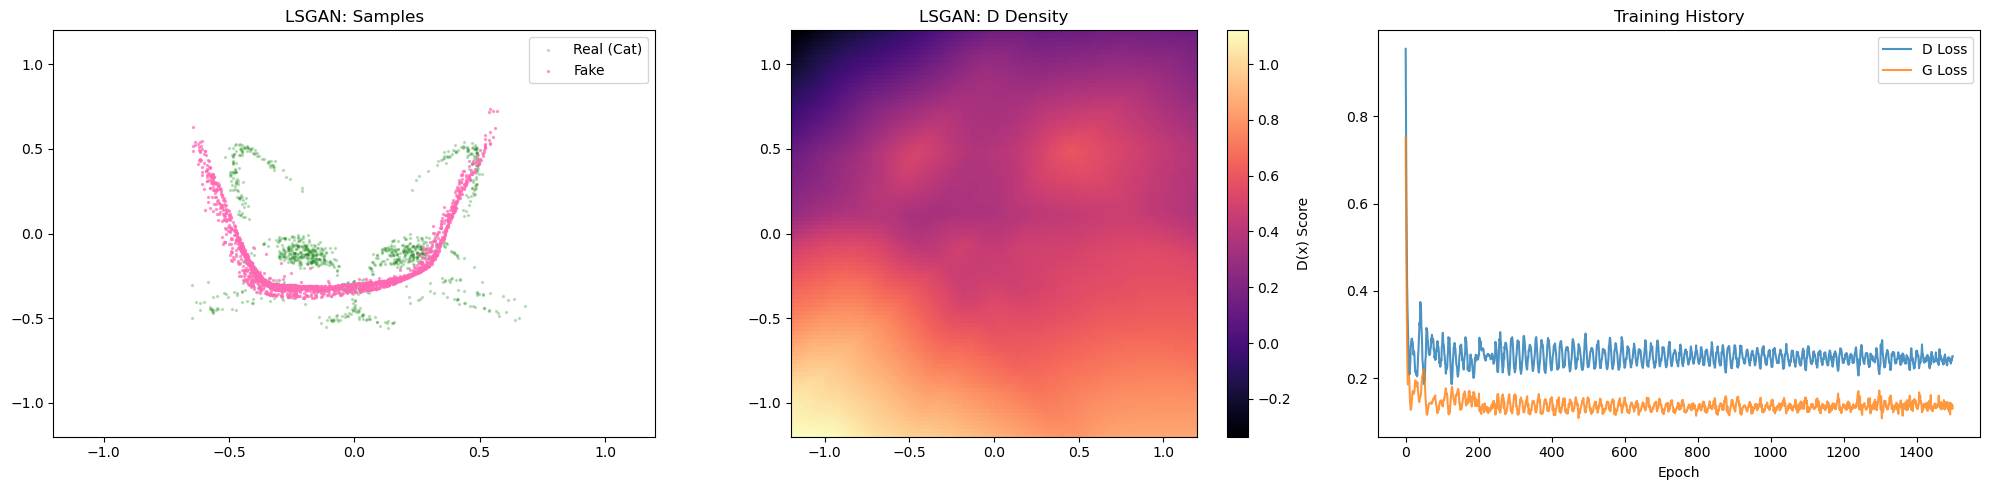

In [22]:
G = Generator().to(device); D = Discriminator(use_sigmoid=False).to(device)
opt_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.9))
opt_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.9))
history = {'d_loss': [], 'g_loss': []}

for epoch in range(epochs):
    real_data = get_cat_samples(batch_size).to(device)
    z = torch.randn(batch_size, 2).to(device)
    fake_data = G(z)

    # D Step (MSE)
    opt_D.zero_grad()
    loss_D = 0.5 * (torch.mean((D(real_data) - 1)**2) + torch.mean(D(fake_data.detach())**2))
    loss_D.backward(); opt_D.step()

    # G Step
    opt_G.zero_grad()
    loss_G = 0.5 * torch.mean((D(fake_data) - 1)**2)
    loss_G.backward(); opt_G.step()
    
    history['d_loss'].append(loss_D.item()); history['g_loss'].append(loss_G.item())

plot_results(G, D, history, "LSGAN")

### 3.4 Wasserstein GAN with Gradient Penalty (WGAN-GP)

WGAN redefines the Discriminator as a **Critic** $f$, which outputs a scalar score rather than a probability.  
It estimates the **Wasserstein (Earth Mover’s) distance**.

##### Objective
$$
\min_G \max_{f\in\mathcal{D}}
\;
\mathbb{E}_{x\sim p_{\text{data}}}[f(x)]
-
\mathbb{E}_{z\sim p_z}[f(G(z))]
$$

##### Lipschitz Constraint
The critic must be **K-Lipschitz continuous**, meaning gradients cannot grow arbitrarily large.

##### Gradient Penalty
$$
\lambda
\mathbb{E}_{\hat{x}\sim p_{\hat{x}}}
\Big[
(\|\nabla_{\hat{x}} f(\hat{x})\|_2 - 1)^2
\Big]
$$

where $ \hat{x} $ is a random interpolation between real and fake samples.
Here, D is a "Critic." The gradient penalty ensures the Critic's gradients are close to 1, preventing the exploding/vanishing gradient issues of Vanilla GAN.

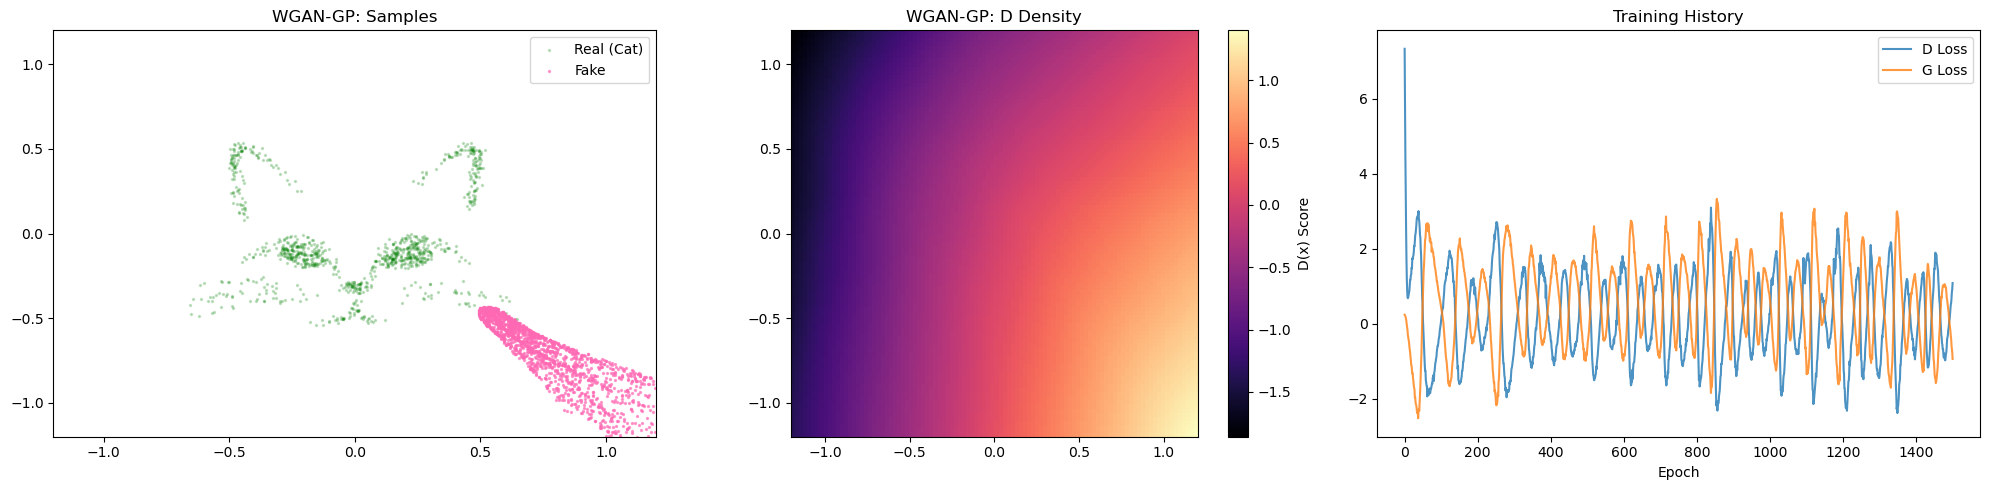

In [26]:
def get_gp(D, real, fake):
    alpha = torch.rand(real.size(0), 1).to(device)
    interp = (alpha * real + (1 - alpha) * fake).requires_grad_(True)
    d_interp = D(interp)
    grad = torch.autograd.grad(outputs=d_interp, inputs=interp, 
                               grad_outputs=torch.ones_like(d_interp),
                               create_graph=True, retain_graph=True)[0]
    return ((grad.norm(2, dim=1) - 1) ** 2).mean() * 10.0

# Training Config
n_critic = 2 # Standard WGAN practice: train D more often than G
G = Generator().to(device)
D = Discriminator(use_sigmoid=False).to(device)

# Use lower betas for WGAN-GP to reduce momentum-induced oscillations. Also smaller learning rate.
opt_G = optim.Adam(G.parameters(), lr=lr/2, betas=(0.5, 0.9))
opt_D = optim.Adam(D.parameters(), lr=lr/2, betas=(0.5, 0.9))

history = {'d_loss': [], 'g_loss': []}

for epoch in range(epochs):
    # --- 1. Train Discriminator (Critic) n_critic times ---
    for _ in range(n_critic):
        real_data = get_cat_samples(batch_size).to(device)
        z = torch.randn(batch_size, 2).to(device)
        fake_data = G(z).detach() # Use detach to avoid training G here

        opt_D.zero_grad()
        # WGAN Loss: Maximize (D(real) - D(fake)) -> Minimize (-D(real) + D(fake))
        d_real = D(real_data)
        d_fake = D(fake_data)
        gp = get_gp(D, real_data, fake_data)
        
        loss_D = -torch.mean(d_real) + torch.mean(d_fake) + gp
        loss_D.backward()
        opt_D.step()

    # --- 2. Train Generator once ---
    opt_G.zero_grad()
    z = torch.randn(batch_size, 2).to(device)
    fake_data = G(z)
    
    # G wants to maximize Critic score for fakes
    loss_G = -torch.mean(D(fake_data))
    loss_G.backward()
    opt_G.step()
    
    history['d_loss'].append(loss_D.item())
    history['g_loss'].append(loss_G.item())

plot_results(G, D, history, "WGAN-GP")



### 3.5 "Long Live the GAN": R1 Regularization

Modern architectures (e.g., StyleGAN) often use the **Non-Saturating loss** combined with an **R1 gradient penalty**.

**Idea:**  
Penalize the Discriminator gradients **only on real samples**, preventing sharp peaks around real data points and improving stability.

##### R1 Penalty
$$
R_1(\psi)
=
\frac{\gamma}{2}
\mathbb{E}_{x\sim p_{\text{data}}}
\Big[
\|\nabla D_\psi(x)\|_2^2
\Big]
$$

**Result:**  
Encourages flatter gradients on the real data manifold, making training more stable and reducing oscillations and mode collapse. This is the "gold standard" for stability in models like StyleGAN. It penalizes the Discriminator for having gradients on the real data.


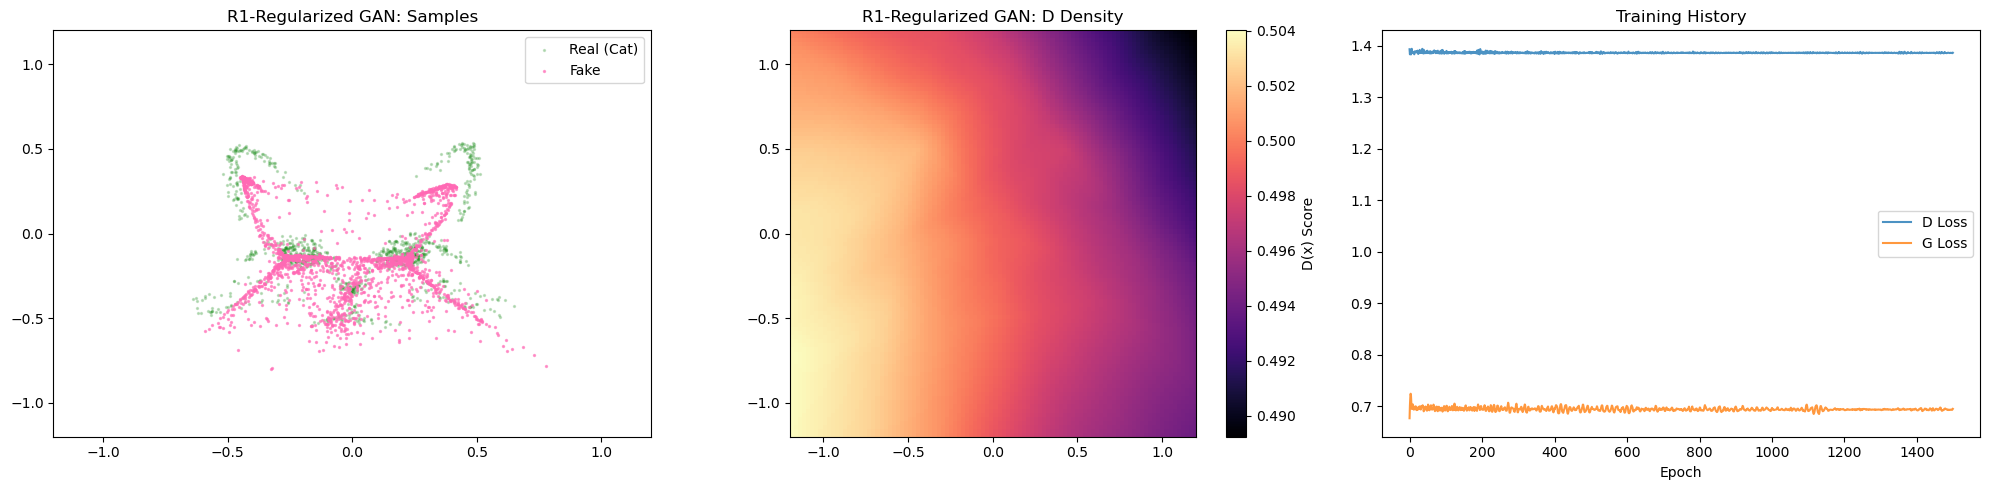

In [24]:
def get_r1(D, real):
    real.requires_grad_(True)
    d_real = D(real)
    grad = torch.autograd.grad(outputs=d_real.sum(), inputs=real, create_graph=True)[0]
    return grad.pow(2).sum(1).mean() * 10.0

G = Generator().to(device); D = Discriminator(use_sigmoid=True).to(device)
opt_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.9))
opt_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.9))
history = {'d_loss': [], 'g_loss': []}

for epoch in range(epochs):
    real_data = get_cat_samples(batch_size).to(device)
    fake_data = G(torch.randn(batch_size, 2).to(device))

    # D Step
    opt_D.zero_grad()
    loss_D = criterion(D(real_data), torch.ones(batch_size, 1).to(device)) + \
             criterion(D(fake_data.detach()), torch.zeros(batch_size, 1).to(device)) + \
             get_r1(D, real_data)
    loss_D.backward(); opt_D.step()

    # G Step
    opt_G.zero_grad()
    loss_G = criterion(D(fake_data), torch.ones(batch_size, 1).to(device))
    loss_G.backward(); opt_G.step()
    
    history['d_loss'].append(loss_D.item()); history['g_loss'].append(loss_G.item())

plot_results(G, D, history, "R1-Regularized GAN")

# 4 Image Generation

We will now train R1-GAN as above but for MNIST images.

In [ ]:
# 1. Setup MNIST Data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # Scale to [-1, 1]
])
mnist_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
mnist_loader = DataLoader(mnist_data, batch_size=64, shuffle=True)

# 2. Re-initialize Models for Image Dimensions
# We keep the MLP structure but change input/output sizes
class MNIST_Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.LeakyReLU(0.2),
            nn.Linear(256, 512), nn.LeakyReLU(0.2),
            nn.Linear(512, 1024), nn.LeakyReLU(0.2),
            nn.Linear(1024, 784), nn.Tanh() # Output matches normalized pixel range
        )
    def forward(self, z): return self.net(z).view(-1, 1, 28, 28)

class MNIST_Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 512), nn.LeakyReLU(0.2),
            nn.Linear(512, 256), nn.LeakyReLU(0.2),
            nn.Linear(256, 1), nn.Sigmoid()
        )
    def forward(self, x): return self.net(x.view(-1, 784))

latent_dim = 100
G = MNIST_Generator(latent_dim).to(device)
D = MNIST_Discriminator().to(device)
opt_G = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
criterion = nn.BCELoss()

# 3. Training Loop with R1 Penalty
history = {'d_loss': [], 'g_loss': []}
num_epochs = 20

print("Starting MNIST Training with R1 Penalty...")
for epoch in range(num_epochs):
    for i, (real_imgs, _) in enumerate(mnist_loader):
        batch_sz = real_imgs.size(0)
        real_imgs = real_imgs.to(device)
        
        # --- Train Discriminator ---
        opt_D.zero_grad()
        
        # R1 Penalty calculation
        real_imgs.requires_grad_(True)
        d_real = D(real_imgs)
        # Gradient of D output w.r.t. real images
        grad_real = torch.autograd.grad(outputs=d_real.sum(), inputs=real_imgs, create_graph=True)[0]
        r1_penalty = grad_real.pow(2).view(batch_sz, -1).sum(1).mean() * 10.0 # Gamma = 10
        
        z = torch.randn(batch_sz, latent_dim).to(device)
        fake_imgs = G(z)
        d_fake = D(fake_imgs.detach())
        
        loss_D = criterion(d_real, torch.ones(batch_sz, 1).to(device)) + \
                 criterion(d_fake, torch.zeros(batch_sz, 1).to(device)) + \
                 r1_penalty
        loss_D.backward()
        opt_D.step()
        
        # --- Train Generator ---
        opt_G.zero_grad()
        loss_G = criterion(D(fake_imgs), torch.ones(batch_sz, 1).to(device))
        loss_G.backward()
        opt_G.step()
        
    history['d_loss'].append(loss_D.item())
    history['g_loss'].append(loss_G.item())
    if (epoch+1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] | D Loss: {loss_D.item():.4f} | G Loss: {loss_G.item():.4f}")

# 4. Final Visualization
with torch.no_grad():
    sample_z = torch.randn(64, latent_dim).to(device)
    samples = G(sample_z).cpu()
    grid = make_grid(samples, nrow=8, normalize=True)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['d_loss'], label='D Loss')
plt.plot(history['g_loss'], label='G Loss')
plt.title("MNIST R1 Training History")
plt.legend()

plt.subplot(1, 2, 2)
plt.imshow(grid.permute(1, 2, 0))
plt.title("Generated MNIST Samples")
plt.axis('off')
plt.show()

Starting MNIST Training with R1 Penalty...
Epoch [5/20] | D Loss: 0.5878 | G Loss: 1.5436
Epoch [10/20] | D Loss: 1.2151 | G Loss: 1.1519
